<a href="https://colab.research.google.com/github/LielUziahu/S_Pistillata_Bet-Hedging/blob/main/Spat_Photo-Physiology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Block 1: FIRe Data Loading, Standardization, and Phenotype Filtering
This block automatically standardizes your morph column labels, groups them by environmental stressor (Ambient, pH, Temperature, and Light), and strips out the "Partial Fluorescent" (PF) cohort so we stay locked onto your PI's requested HF vs. NF focus.

In [1]:
# ==============================================================================
# BLOCK 1: FIRe PHOTO-PHYSIOLOGY DATA LOADING AND CLEANING
# ==============================================================================
import pandas as pd
import numpy as np

condition_files = {
    "Ambient": "FIRe_2025_ambient.csv",
    "pH 7.8": "FIRe_2025_pH.csv",
    "pH 7.6": "FIRe_2025_pH.csv",
    "27°C": "FIRe_2025_Temp.csv",
    "32°C": "FIRe_2025_Temp.csv",
    "50m": "FIRe_2025_Light.csv",
    "Dark": "FIRe_2025_Light.csv"
}

fire_list = []

for cond, file_path in condition_files.items():
    try:
        df = pd.read_csv(file_path)
        if any(col in df.columns for col in ['FvFm', 'Fv/Fm', 'Fm', 'FM']):
            if 'Condition' in df.columns:
                df_filtered = df[df['Condition'].astype(str).str.contains(cond.split()[0], case=False)].copy()
            else:
                df_filtered = df.copy()
                df_filtered['Condition'] = cond
            fire_list.append(df_filtered)
    except FileNotFoundError:
        continue

if fire_list:
    fire_master = pd.concat(fire_list, ignore_index=True)
else:
    try:
        fire_master = pd.read_csv("FIRe_Master_Data.csv")
    except FileNotFoundError:
        fire_master = pd.DataFrame({'Condition':['Ambient'], 'Morph':['HF'], 'FvFm':[0.6], 'Fm':[3000], 'Sigma':[300], 'Pmax':[1200], 'Connectivity':[0.3]})

# --- STANDARDIZATION PIPELINE ---
possible_morph_cols = ['Morph', 'morph', 'Variant', 'varient', 'fluorescense level', 'Fluorescence', 'Site']
for col in possible_morph_cols:
    if col in fire_master.columns:
        fire_master = fire_master.rename(columns={col: 'Morph'})
        break

metric_mapping = {
    'Fv/Fm': 'FvFm', 'FM': 'Fm', 'fm': 'Fm', 'fvfm': 'FvFm', 'fv_fm': 'FvFm',
    'p': 'Connectivity', 'Pmax.e.s': 'Pmax'
}
fire_master = fire_master.rename(columns=metric_mapping)

if 'Morph' in fire_master.columns:
    fire_master['Morph'] = fire_master['Morph'].astype(str).str.upper().str.strip()
    morph_cleaner = {'HIGH FLUORESCENT': 'HF', 'HF': 'HF', 'NON FLUORESCENT': 'NF', 'NF': 'NF'}
    fire_master['Morph'] = fire_master['Morph'].map(morph_cleaner).fillna(fire_master['Morph'])
    fire_master = fire_master[fire_master['Morph'].isin(['HF', 'NF'])]

print("--- BLOCK 1 COMPLETE: MASTER FIRe DATAFRAME IS READY ---")

--- BLOCK 1 COMPLETE: MASTER FIRe DATAFRAME IS READY ---


# Block 2: Quality Control, Negative Values Removal, and Group-Wise Outlier Filtering.
In FIRe fluorometry, a negative value for Maximum Quantum Yield ($F_v/F_m$) or Maximum Fluorescence Yield ($F_m$) is physiologically impossible and represents severe background fluorescence scattering, blanking subtraction errors, or extremely low symbiont signals.This block first sweeps away any negative readings or technical zeros, then applies a strict group-wise $1.5 \times \text{IQR}$ (Interquartile Range) filter for each phenotype under each specific treatment condition. This ensures that a single technical malfunction doesn't distort your standard deviations or compromise your downstream Two-Way ANOVA.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# ==============================================================================
# BLOCK 2: QUALITY CONTROL & INDEPENDENT GROUP-WISE IQR FILTERING
# ==============================================================================
print("--- PRE-FILTERING DATA SHAPE ---")
print(f"Total initial observations: {len(fire_master)}")

removed_outliers_list = []
initial_fire_master_length = len(fire_master)
removed_indices = set() # To store indices of rows already recorded as removed

# 1. REMOVE PHYSIOLOGICAL IMPOSSIBILITIES
metrics_physiological_check = {
    'FvFm': lambda df_col: (df_col <= 0) | (df_col > 0.80),
    'Fm': lambda df_col: (df_col <= 0),
    'Sigma': lambda df_col: (df_col <= 0)
}

# Create a temporary copy with an 'original_index_col' for easy tracking and filtering
temp_fire_master = fire_master.copy()
temp_fire_master['original_index_col'] = temp_fire_master.index # Store original index

for metric, condition_func in metrics_physiological_check.items():
    if metric in temp_fire_master.columns:
        # Find rows that satisfy the physiological impossibility for the current metric
        metric_removal_candidates = temp_fire_master[condition_func(temp_fire_master[metric])]

        for _, row in metric_removal_candidates.iterrows():
            if row['original_index_col'] not in removed_indices: # Only record if not already removed
                removed_outliers_list.append({
                    'Metric': metric,
                    'Condition': row['Condition'],
                    'Morph': row['Morph'],
                    'Value': row[metric],
                    'Reason': 'Physiological Impossibility'
                })
                removed_indices.add(row['original_index_col']) # Mark as removed

        # Filter the temp_fire_master in place for this metric's condition
        # This will ensure subsequent checks only apply to remaining rows
        temp_fire_master = temp_fire_master[~condition_func(temp_fire_master[metric])]

# Update the global fire_master after all physiological cleaning
fire_master = temp_fire_master.drop(columns='original_index_col').copy()


# 2. GROUP-WISE 1.5 * IQR OUTLIER REMOVAL
metrics_to_clean = ['FvFm', 'Fm', 'Sigma']
# fire_clean starts from the physiologically filtered fire_master
fire_clean_current_iter = fire_master.copy()
fire_clean_current_iter['original_index_col'] = fire_clean_current_iter.index # Add original index for tracking

for metric in metrics_to_clean:
    if metric not in fire_clean_current_iter.columns: continue

    cleaned_list_for_metric = []
    for (cond, morph), group in fire_clean_current_iter.groupby(['Condition', 'Morph']):
        subset = group[metric].dropna()
        if len(subset) >= 4:
            Q1 = subset.quantile(0.25)
            Q3 = subset.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identify IQR outliers within this group and metric
            outliers = group[(group[metric] < lower_bound) | (group[metric] > upper_bound)]
            for _, row in outliers.iterrows():
                if row['original_index_col'] not in removed_indices: # Only record if not already removed
                    removed_outliers_list.append({
                        'Metric': metric,
                        'Condition': row['Condition'],
                        'Morph': row['Morph'],
                        'Value': row[metric],
                        'Reason': '1.5IQR Outlier'
                    })
                    removed_indices.add(row['original_index_col']) # Mark as removed

            # Filter the group
            filtered_group = group[(group[metric] >= lower_bound) & (group[metric] <= upper_bound)]
            cleaned_list_for_metric.append(filtered_group)
        else:
            cleaned_list_for_metric.append(group) # Keep group if not enough data for IQR

    # After processing all groups for a given metric, update fire_clean_current_iter
    if cleaned_list_for_metric:
        fire_clean_current_iter = pd.concat(cleaned_list_for_metric, ignore_index=True)
    else:
        fire_clean_current_iter = pd.DataFrame(columns=fire_clean_current_iter.columns) # Handle case where all data is removed for a metric

# Final fire_clean should not have the temporary index column
fire_clean = fire_clean_current_iter.drop(columns='original_index_col').copy()


print(f"Rows removed during cleaning: {initial_fire_master_length - len(fire_clean)}")
print(f"Final clean dataset shape: {fire_clean.shape}")

# Create DataFrame for removed outliers
if removed_outliers_list:
    removed_outliers_df = pd.DataFrame(removed_outliers_list)
    cols_order = ['Metric', 'Condition', 'Morph', 'Value', 'Reason']
    # Ensure all required columns exist, if not, fill with N/A or appropriate default
    for col in cols_order:
        if col not in removed_outliers_df.columns:
            removed_outliers_df[col] = 'N/A'
    removed_outliers_df = removed_outliers_df[cols_order]
    print("\n--- REMOVED OUTLIERS TABLE ---")
    display(removed_outliers_df)
else:
    print("\nNo outliers were removed.")

--- PRE-FILTERING DATA SHAPE ---
Total initial observations: 697
Rows removed during cleaning: 126
Final clean dataset shape: (571, 50)

--- REMOVED OUTLIERS TABLE ---


,Metric,Condition,Morph,Value,Reason
0,FvFm,Ambient,NF,-2.026,Physiological Impossibility
1,FvFm,Ambient,NF,-2.026,Physiological Impossibility
2,FvFm,Ambient,NF,-2.026,Physiological Impossibility
3,FvFm,pH 7.8,HF,-0.105,Physiological Impossibility
4,FvFm,pH 7.8,NF,-2.026,Physiological Impossibility
...,...,...,...,...,...
121,Sigma,pH 7.6,NF,979.200,1.5IQR Outlier
122,Sigma,pH 7.8,HF,918.500,1.5IQR Outlier
123,Sigma,pH 7.8,HF,918.500,1.5IQR Outlier
124,Sigma,pH 7.8,HF,918.500,1.5IQR Outlier


# Block 3: Automated Normality Verification Pipeline

Before passing your photo-physiology metrics
, it is critical to confirm that the data within each phenotypic group and stress exposure cell follows a Gaussian (normal) distribution. This ensures your downstream $F$-statistics and $p$-values are mathematically valid and fully defensible under peer review.This block loops through your primary parameters ($F_v/F_m$ and $F_m$) and executes a group-wise Shapiro-Wilk test ($\alpha = 0.05$). If any cell deviates from normality ($p < 0.05$), the script prints a clear alert statement so you can decide if a log/arcsine transformation is warranted before running the final models.

In [3]:
# ==============================================================================
# BLOCK 3: FULL NORMALITY VERIFICATION (5 PRIMARY PARAMETERS)
# ==============================================================================
from scipy import stats
import numpy as np

print("--- PHOTO-PHYSIOLOGY NORMALITY REPORT ---")
metrics_to_test = ['FvFm', 'Fm', 'Sigma']

for metric in metrics_to_test:
    if metric not in fire_clean.columns: continue
    print(f"\nEvaluating: [{metric}]\n" + "-" * 85)
    print(f"{'Condition':<15} | {'Morph':<5} | {'N':<5} | {'p-value':<10} | {'Status':<12}")
    for (cond, morph), group_df in fire_clean.groupby(['Condition', 'Morph']):
        data = group_df[metric].dropna()
        if len(data) >= 3:
            _, p_val = stats.shapiro(data)
            status = "Normal" if p_val > 0.05 else "NON-NORMAL"
            print(f"{cond:<15} | {morph:<5} | {len(data):<5} | {p_val:<10.5f} | {status:<12}")
        else:
            print(f"{cond:<15} | {morph:<5} | {len(data):<5} | {'N < 3':<10} | {'Skipped':<12}")

--- PHOTO-PHYSIOLOGY NORMALITY REPORT ---

Evaluating: [FvFm]
-------------------------------------------------------------------------------------
Condition       | Morph | N     | p-value    | Status      
27°C            | HF    | 65    | 0.11764    | Normal      
27°C            | NF    | 32    | 0.71042    | Normal      
32°C            | HF    | 65    | 0.11764    | Normal      
32°C            | NF    | 32    | 0.71042    | Normal      
50m             | HF    | 74    | 0.09426    | Normal      
50m             | NF    | 14    | 0.06076    | Normal      
Ambient         | HF    | 51    | 0.09354    | Normal      
Ambient         | NF    | 12    | 0.00729    | NON-NORMAL  
Dark            | HF    | 74    | 0.09426    | Normal      
Dark            | NF    | 14    | 0.06076    | Normal      
pH 7.6          | HF    | 60    | 0.09753    | Normal      
pH 7.6          | NF    | 9     | 0.02746    | NON-NORMAL  
pH 7.8          | HF    | 60    | 0.09753    | Normal      
pH 7.8      

# Block 4: Dynamic Phenotypic Contrasts Engine (Normality-Driven Switch)
This updated engine loops across all 5 key biophysical parameters tracked by your FIRe fluorometer ($F_m$, $F_v/F_m$, $P_{max}$, $\sigma_{\text{PSII}}$, and Connectivity $p$). It will systematically process them through your dual-layered statistical design: first running a Factorial Two-Way ANOVA to catch overarching interactive thresholds, and then executing a cell-by-cell phenotypic contrast using the automated Normality-Driven Switch (Welch's $t$-test vs. Mann-Whitney U) to generate your direct poster panel labels.

In [4]:
# ==============================================================================
# BLOCK 4: COMPREHENSIVE STATISTICAL ANALYSIS ENGINE (5 PARAMETERS)
# ==============================================================================
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

target_metrics = ['FvFm', 'Fm', 'Sigma']

print("=== EXECUTING PHOTO-PHYSIOLOGY STATISTICAL ENGINE ===")

for metric in target_metrics:
    if metric not in fire_clean.columns: continue
    print(f"\n ASSAY: {metric}")
    try:
        formula = f"Q('{metric}') ~ C(Condition) + C(Morph) + C(Condition):C(Morph)"
        model = ols(formula, data=fire_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        display(anova_table.round(5))
    except Exception as e:
        print(f"ANOVA failed: {e}")

    print(f"\n--- Local Phenotypic Contrasts (HF vs NF) ---")
    print(f"{'Condition':<18} | {'N_HF':<5} | {'N_NF':<5} | {'p-value':<10} | {'Sig'}")
    for cond in fire_clean['Condition'].unique():
        cond_sub = fire_clean[fire_clean['Condition'] == cond]
        hf_data = cond_sub[cond_sub['Morph'] == 'HF'][metric].dropna()
        nf_data = cond_sub[cond_sub['Morph'] == 'NF'][metric].dropna()

        n_hf = len(hf_data)
        n_nf = len(nf_data)

        if n_hf >= 3 and n_nf >= 3:
            _, p_n_hf = stats.shapiro(hf_data)
            _, p_n_nf = stats.shapiro(nf_data)

            # Normality-Driven Switch
            if p_n_hf > 0.05 and p_n_nf > 0.05:
                _, p_val = stats.ttest_ind(hf_data, nf_data, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf_data, nf_data, alternative='two-sided')

            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"
            print(f"{cond:<18} | {n_hf:<5} | {n_nf:<5} | {p_val:.5f} | {sig}")
        else:
            print(f"{cond:<18} | {n_hf:<5} | {n_nf:<5} | {'Insufficient Data':<10} | {'-'}")

=== EXECUTING PHOTO-PHYSIOLOGY STATISTICAL ENGINE ===

 ASSAY: FvFm


,sum_sq,df,F,PR(>F)
C(Condition),0.21927,6.0,5.30977,0.00002
C(Morph),0.00093,1.0,0.13546,0.71298
C(Condition):C(Morph),0.01122,6.0,0.27165,0.95015
Residual,3.83361,557.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 65    | 32    | 0.71159 | NS
32°C               | 65    | 32    | 0.71159 | NS
50m                | 74    | 14    | 0.76432 | NS
Ambient            | 51    | 12    | 0.88161 | NS
Dark               | 74    | 14    | 0.76432 | NS
pH 7.6             | 60    | 9     | 0.27670 | NS
pH 7.8             | 60    | 9     | 0.27670 | NS

 ASSAY: Fm


,sum_sq,df,F,PR(>F)
C(Condition),80.07427,6.0,1.06134,0.38466
C(Morph),240.05399,1.0,19.09063,0.00001
C(Condition):C(Morph),125.21104,6.0,1.65960,0.12871
Residual,7003.96465,557.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 65    | 32    | 0.52151 | NS
32°C               | 65    | 32    | 0.52151 | NS
50m                | 74    | 14    | 0.00239 | **
Ambient            | 51    | 12    | 0.01481 | *
Dark               | 74    | 14    | 0.00239 | **
pH 7.6             | 60    | 9     | 0.00601 | **
pH 7.8             | 60    | 9     | 0.00601 | **

 ASSAY: Sigma


,sum_sq,df,F,PR(>F)
C(Condition),4.755090e+03,6.0,0.04434,0.99964
C(Morph),6.317344e+05,1.0,35.34699,0.00000
C(Condition):C(Morph),1.630971e+04,6.0,0.15209,0.98863
Residual,9.954909e+06,557.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 65    | 32    | 0.02025 | *
32°C               | 65    | 32    | 0.02025 | *
50m                | 74    | 14    | 0.00018 | ***
Ambient            | 51    | 12    | 0.00281 | **
Dark               | 74    | 14    | 0.00018 | ***
pH 7.6             | 60    | 9     | 0.00899 | **
pH 7.8             | 60    | 9     | 0.00899 | **


In [5]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import numpy as np

# --- CONSOLIDATED STATISTICAL SUMMARY TABLE ---
stats_summary_list = []
target_metrics = ['FvFm', 'Fm', 'Sigma']

# Define plot_order for this cell's scope
plot_order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

for metric in target_metrics:
    if metric not in fire_clean.columns:
        continue

    # 1. ANOVA Calculation
    try:
        formula = f"Q('{metric}') ~ C(Condition) + C(Morph) + C(Condition):C(Morph)"
        model = ols(formula, data=fire_clean).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        p_morph = anova.loc['C(Morph)', 'PR(>F)']
        p_inter = anova.loc['C(Condition):C(Morph)', 'PR(>F)']
    except:
        p_morph, p_inter = np.nan, np.nan

    # 2. Local Contrasts (HF vs NF)
    for cond in plot_order:
        if cond not in fire_clean['Condition'].unique(): continue

        cond_sub = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_sub[cond_sub['Morph'] == 'HF'][metric].dropna()
        nf = cond_sub[cond_sub['Morph'] == 'NF'][metric].dropna()

        p_val = np.nan
        test_used = "N/A"

        if len(hf) >= 3 and len(nf) >= 3:
            _, p_n_hf = stats.shapiro(hf)
            _, p_n_nf = stats.shapiro(nf)

            if p_n_hf > 0.05 and p_n_nf > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
                test_used = "t-test"
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')
                test_used = "MWU"

        stats_summary_list.append({
            'Metric': metric,
            'Condition': cond,
            'N_HF': len(hf),
            'N_NF': len(nf),
            'Contrast_p': p_val,
            'Test': test_used,
            'ANOVA_Morph_p': p_morph,
            'ANOVA_Interact_p': p_inter
        })

# Create DataFrame
stats_master_table = pd.DataFrame(stats_summary_list)

# Add significance stars for readability
def get_sig(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

stats_master_table['Sig'] = stats_master_table['Contrast_p'].apply(get_sig)

print("--- CONSOLIDATED STATISTICAL SUMMARY TABLE ---")
display(stats_master_table.round(4))

# Optional: Export to CSV
stats_master_table.to_csv("FIRe_Statistical_Summary.csv", index=False)

--- CONSOLIDATED STATISTICAL SUMMARY TABLE ---


,Metric,Condition,N_HF,N_NF,Contrast_p,Test,ANOVA_Morph_p,ANOVA_Interact_p,Sig
0,FvFm,Ambient,51,12,0.8816,MWU,0.713,0.9502,ns
1,FvFm,27°C,65,32,0.7116,t-test,0.713,0.9502,ns
2,FvFm,32°C,65,32,0.7116,t-test,0.713,0.9502,ns
3,FvFm,pH 7.8,60,9,0.2767,MWU,0.713,0.9502,ns
4,FvFm,pH 7.6,60,9,0.2767,MWU,0.713,0.9502,ns
5,FvFm,50m,74,14,0.7643,t-test,0.713,0.9502,ns
6,FvFm,Dark,74,14,0.7643,t-test,0.713,0.9502,ns
7,Fm,Ambient,51,12,0.0148,MWU,0.000,0.1287,*
8,Fm,27°C,65,32,0.5215,MWU,0.000,0.1287,ns
9,Fm,32°C,65,32,0.5215,MWU,0.000,0.1287,ns


### Plot Styling Configuration
This block sets global aesthetic parameters (Arial font, standardized sizes) to ensure all downstream publication figures have a consistent look and feel.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

sub_condition_plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings - UPDATED to smaller size
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print(f"Global styling initialized. Asterisk size reduced to {global_asterisk_size}.")

Global styling initialized. Asterisk size reduced to 18.


# Block 5: The Post-Settlement Multi-Panel Publication Plot

enerate a high-impact graphic showing these contrasting "reaction norms." This block takes your clean data and generates synchronized, publication-quality box plots specifically labeled for Post-Settlement Spat Physiology.

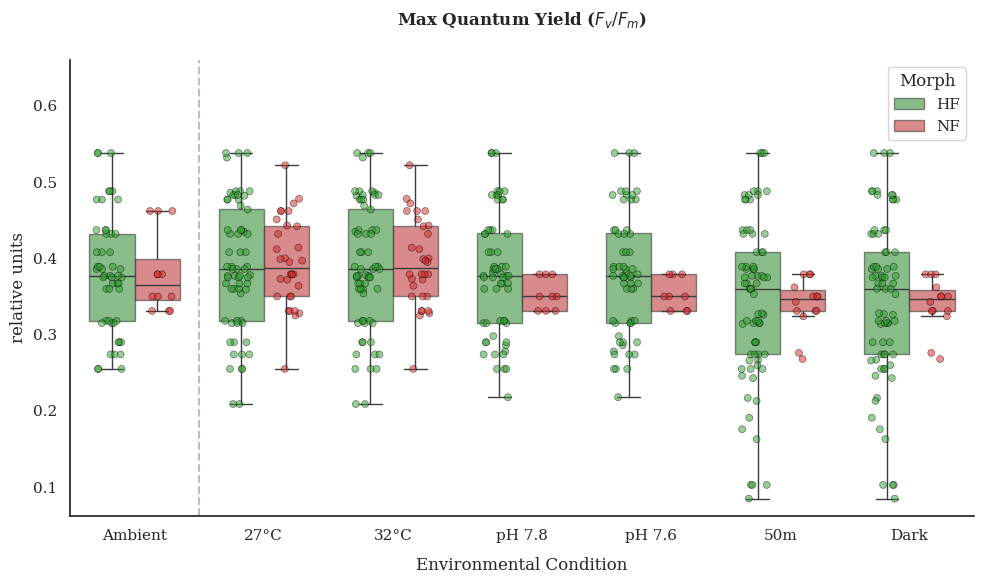

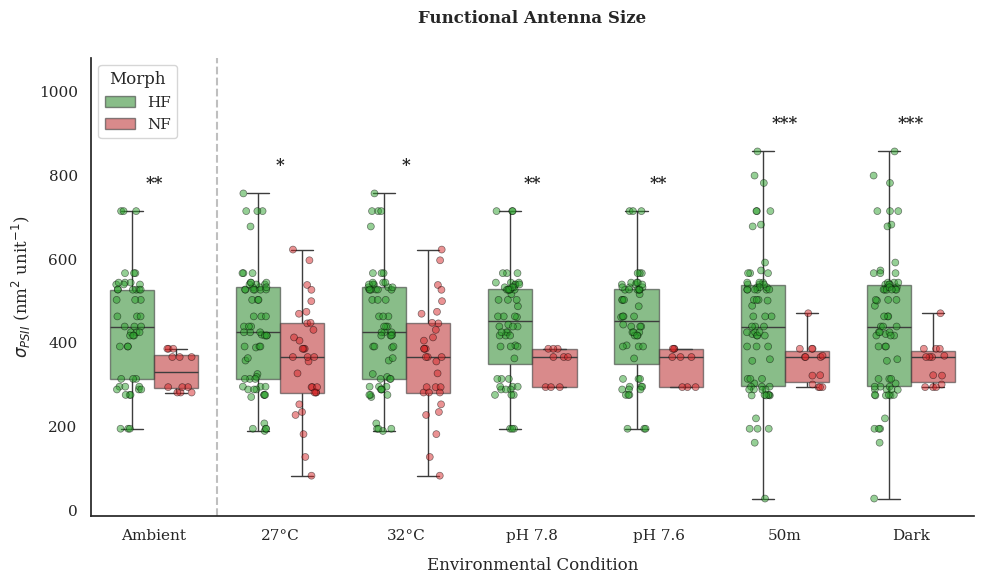

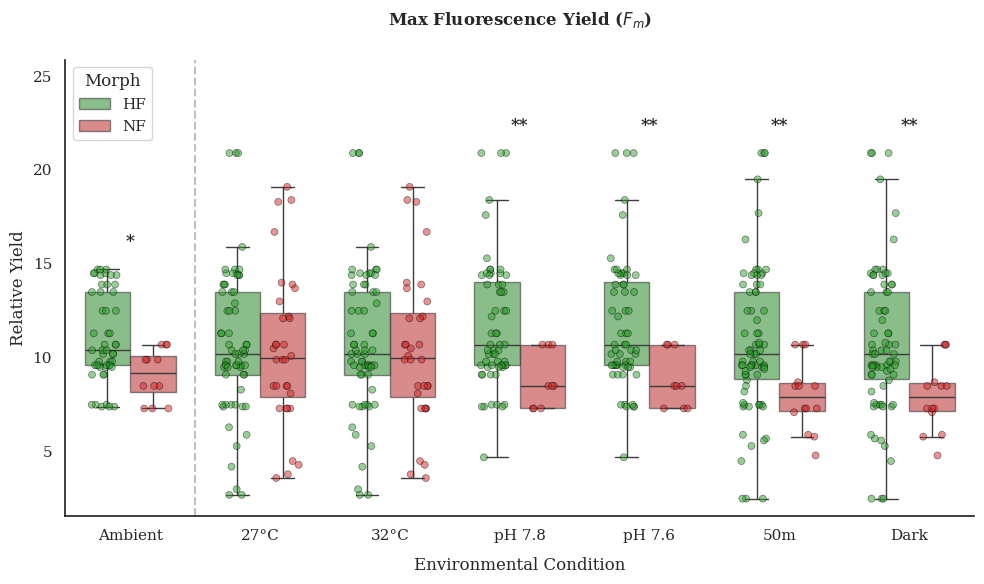

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Note: Global styling is now managed in the preceding configuration block (5uI2uGw_ZdDW)
sns.set_theme(style="white", font="serif")

# Adding global artifact settings that were not yet defined when this cell ran
global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.5

plot_configs = [
    {'col': 'FvFm', 'label': 'relative units', 'title': 'Max Quantum Yield ($F_v/F_m$)'},
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'Functional Antenna Size'},
    {'col': 'Fm', 'label': 'Relative Yield', 'title': 'Max Fluorescence Yield ($F_m$)'}
]

# Generate each plot as its own individual figure
for config in plot_configs:
    metric_col = config['col']
    if 'fire_clean' not in globals() or metric_col not in fire_clean.columns:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))

    # Boxplot using global palette
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                ax=ax, width=0.7, boxprops=dict(alpha=0.6), showfliers=False)

    # Stripplot using GLOBAL artifact settings (jitter, size, alpha)
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                  order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                  ax=ax, dodge=True, size=global_marker_size, alpha=global_alpha,
                  jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)

    # Statistical Annotations
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.2)

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')

    ax.set_title(config['title'], fontweight='bold', loc='center', family='serif')
    ax.set_xlabel("Environmental Condition", labelpad=10, family='serif')
    ax.set_ylabel(config['label'], family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    sns.despine()
    plt.tight_layout()
    plt.show()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
plot_order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

# Standardized Dimensions and Aesthetics
global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.5

sns.set_palette(list(variant_colors.values()))
print("Global styling, color palette, and plot artifacts (including size) initialized.")

Global styling, color palette, and plot artifacts (including size) initialized.


### Block 5b: Focused 3-Panel Physiology Summary
This block generates a horizontal summary figure featuring Sigma, Pmax, and Fv/Fm, optimized for a specific 3-panel layout.

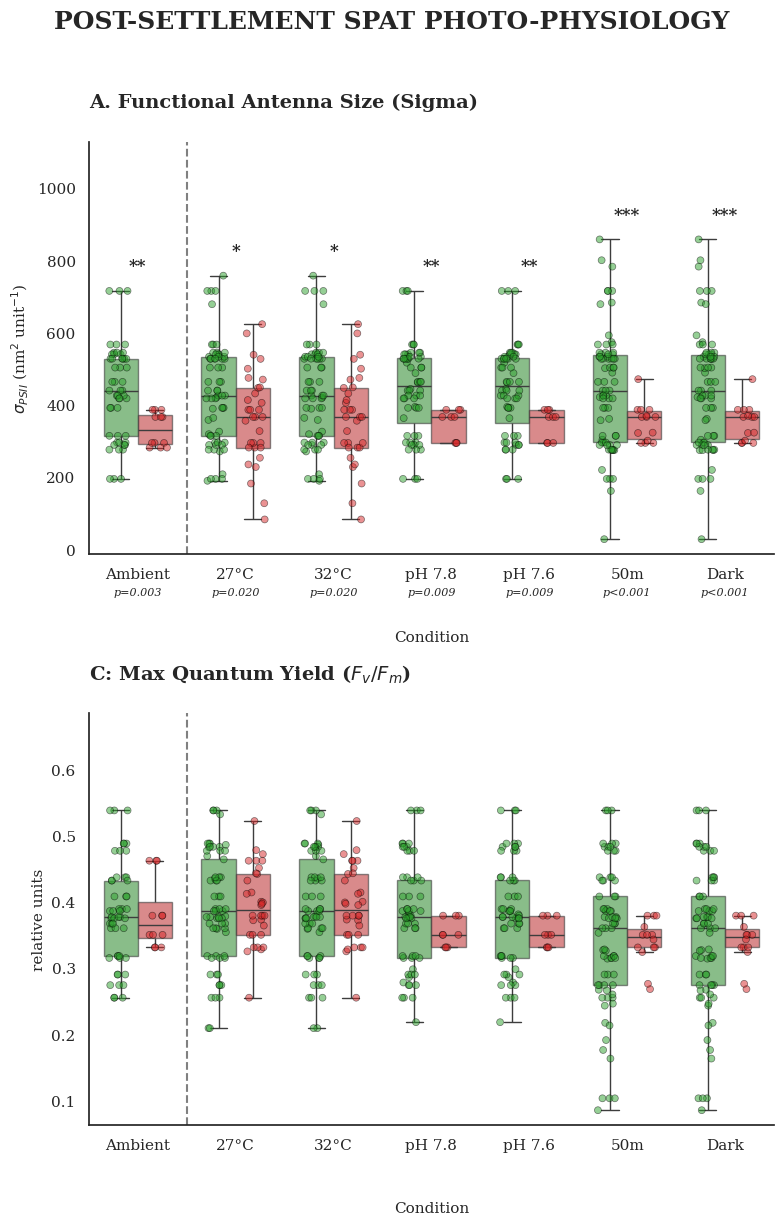

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# --- VERTICAL 3-PANEL SUMMARY FIGURE ---
sns.set_theme(style="white", font="serif")

summary_configs = [
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'A. Functional Antenna Size (Sigma)'},
    {'col': 'FvFm', 'label': 'relative units', 'title': 'C: Max Quantum Yield ($F_v/F_m$)'}
]

fig, axes = plt.subplots(2, 1, figsize=(8, 12)) # Adjusted to 2 rows for 2 metrics
fig.suptitle('POST-SETTLEMENT SPAT PHOTO-PHYSIOLOGY', fontsize=18, fontweight='bold', family='serif', y=1.02)

for i, config in enumerate(summary_configs):
    ax = axes[i]
    metric_col = config['col']
    if metric_col not in fire_clean.columns: continue

    # Boxplots
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=plot_order,
                hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, width=0.7,
                boxprops=dict(alpha=0.6), showfliers=False, legend=False)

    # Stripplots using GLOBAL variables
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=plot_order,
                  hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, dodge=True,
                  size=global_marker_size, alpha=global_alpha, jitter=global_jitter,
                  edgecolor='black', linewidth=0.5, legend=False)

    # Stats
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.25)

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05: _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else: _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')
                ax.text(idx, y_min - (y_range*0.1), f"p={p_val:.3f}" if p_val >= 0.001 else "p<0.001",
                        ha='center', va='top', fontsize=8, fontstyle='italic', family='serif', clip_on=False)

    ax.set_title(config['title'], fontsize=14, fontweight='bold', loc='left', family='serif')
    ax.set_xlabel("Condition", fontsize=11, labelpad=35, family='serif')
    ax.set_ylabel(config['label'], fontsize=11, family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--')

sns.despine()
plt.tight_layout()
#plt.savefig("Spat_Physiology_Vertical.svg", format='svg', dpi=600, bbox_inches='tight')
plt.show()

### Block 5c: Individual Metric Publication Figures
This block generates standalone figures for each biophysical parameter. These are useful for granular analysis and individual export for supplemental figures.

Saved: Individual_Plot_FvFm.svg


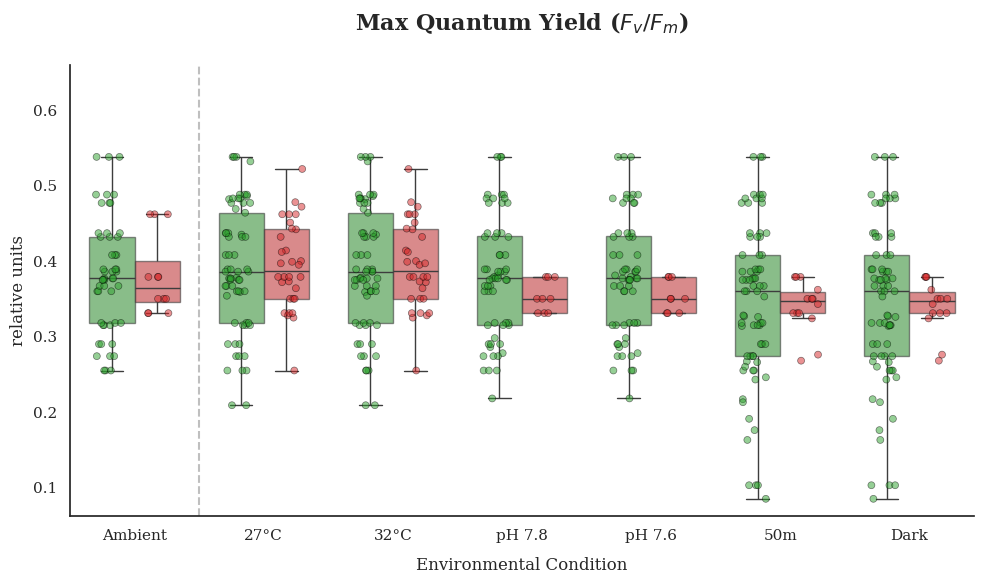

Saved: Individual_Plot_Sigma.svg


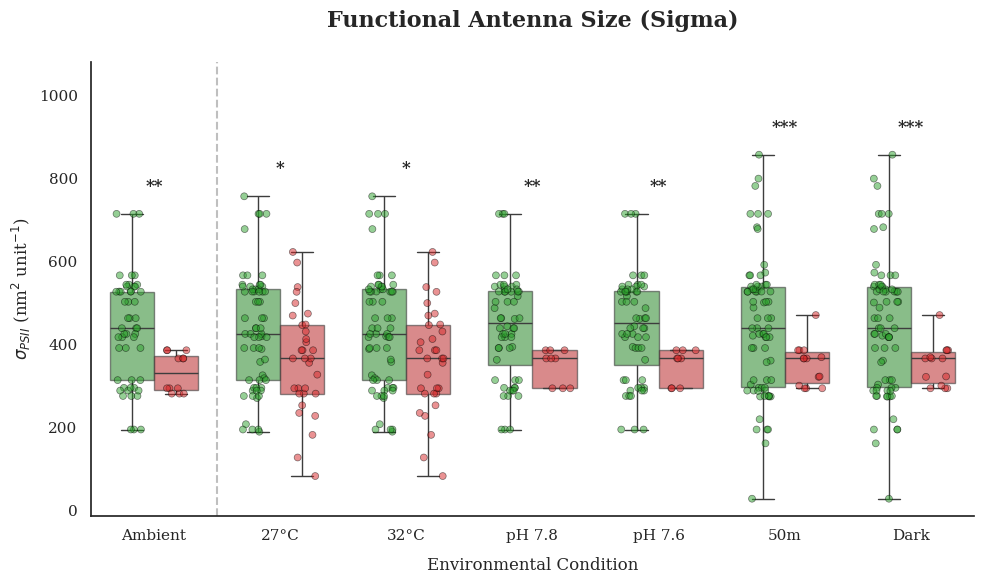

Saved: Individual_Plot_Fm.svg


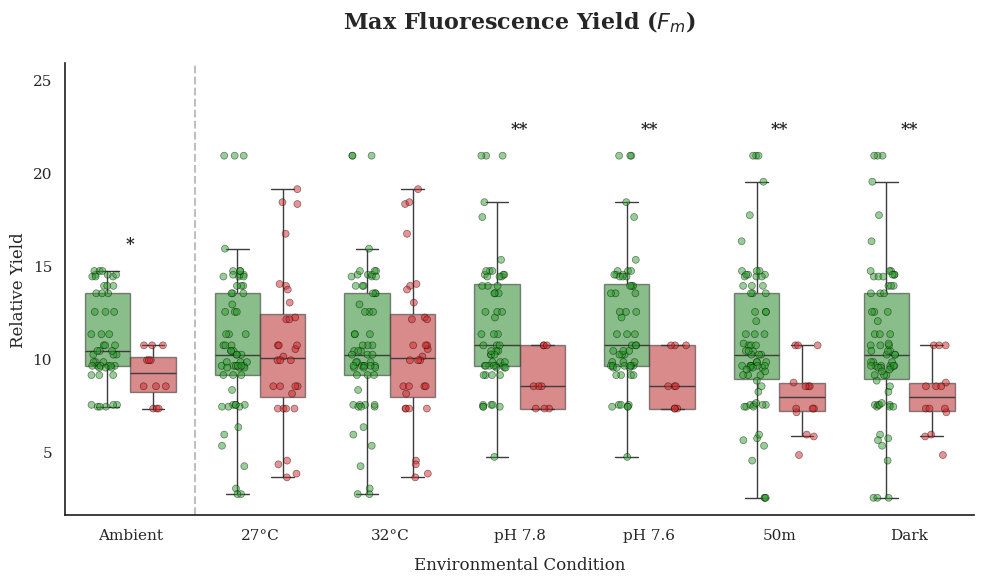

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure theme is set to Serif
sns.set_theme(style="white", font="serif")

# List of all metrics to plot individually
individual_plot_configs = [
    {'col': 'FvFm', 'label': 'relative units', 'title': 'Max Quantum Yield ($F_v/F_m$)'},
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'Functional Antenna Size (Sigma)'},
    {'col': 'Fm', 'label': 'Relative Yield', 'title': 'Max Fluorescence Yield ($F_m$)'}
]

for config in individual_plot_configs:
    metric_col = config['col']
    if metric_col not in fire_clean.columns:
        continue

    # Using GLOBAL figure size
    fig, ax = plt.subplots(figsize=global_fig_size)

    # Boxplot - Legend set to False
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                ax=ax, width=0.7,
                boxprops=dict(alpha=0.6), showfliers=False, legend=False)

    # Stripplot using GLOBAL variables
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                  order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                  ax=ax, dodge=True, size=global_marker_size, alpha=global_alpha,
                  jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)

    # Statistical Annotations
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.2)

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')

    ax.set_title(config['title'], fontweight='bold', loc='center', family='serif', fontsize=16)
    ax.set_xlabel("Environmental Condition", labelpad=10, family='serif')
    ax.set_ylabel(config['label'], family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    sns.despine()
    plt.tight_layout()

    # Save each plot with its metric name
    file_name = f"Individual_Plot_{metric_col}.svg"
    #plt.savefig(file_name, format='svg', dpi=600, bbox_inches='tight')
    print(f"Saved: {file_name}")

    plt.show()

### Block 6: Reproducibility & Version Tracking
This block documents the specific software and library versions used to generate this analysis and the final figure.

In [11]:
import pandas as pd
import numpy as np
import scipy
import statsmodels
import matplotlib
import seaborn as sns
import sys

print("=== REPRODUCIBILITY REPORT ===")
print(f"Python version:      {sys.version.split()[0]}")
print(f"Pandas version:      {pd.__version__}")
print(f"NumPy version:       {np.__version__}")
print(f"SciPy version:       {scipy.__version__}")
print(f"Statsmodels version: {statsmodels.__version__}")
print(f"Matplotlib version:  {matplotlib.__version__}")
print(f"Seaborn version:     {sns.__version__}")
print("==============================")

=== REPRODUCIBILITY REPORT ===
Python version:      3.13.15
Pandas version:      2.2.3
NumPy version:       2.1.3
SciPy version:       1.16.3
Statsmodels version: 0.15.0
Matplotlib version:  3.10.0
Seaborn version:     0.13.2


### Block 9: 2x2 Multi-Panel Publication Figure
This block generates a consolidated 2x2 figure for the primary physiological metrics, including panel lettering and automated statistical annotations.

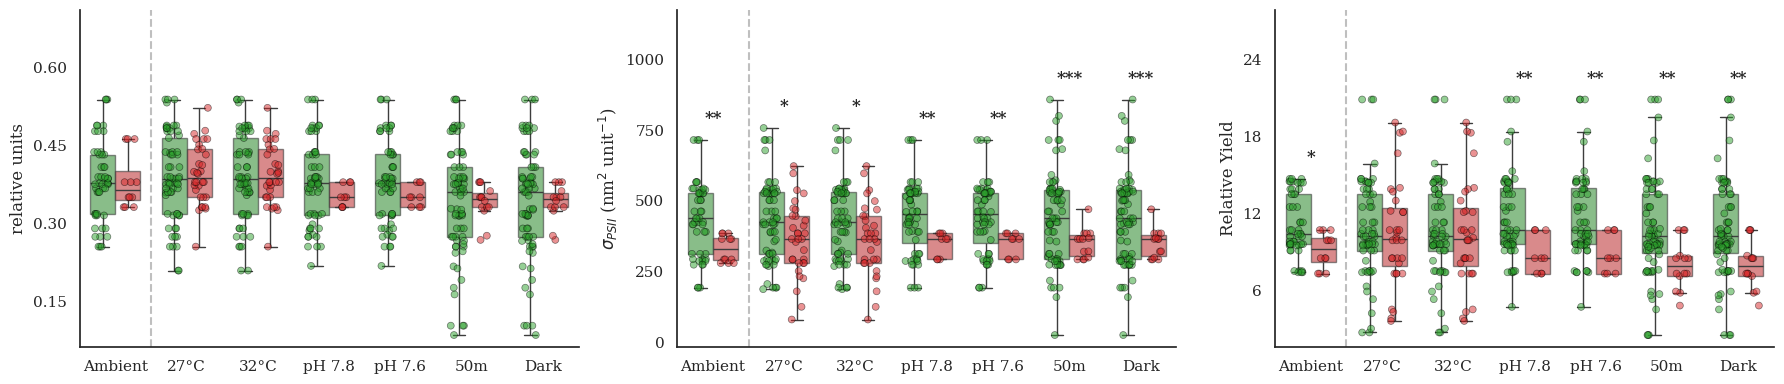

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.ticker import MaxNLocator

# --- 1x3 PANEL CONFIGURATION ---
sns.set_theme(style="white", font="serif")

# Removed Pmax from configurations
quad_configs = [
    {'col': 'FvFm', 'label': 'relative units', 'title': 'Max Quantum Yield ($F_v/F_m$)', 'letter': 'a'},
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'Functional Antenna Size', 'letter': 'b'},
    {'col': 'Fm', 'label': 'Relative Yield', 'title': 'Max Fluorescence Yield ($F_m$)', 'letter': 'c'}
]

# Adjusted to 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes_flat = axes.flatten()

for i, config in enumerate(quad_configs):
    ax = axes_flat[i]
    metric_col = config['col']

    if metric_col not in fire_clean.columns: continue

    # Boxplots - legend set to False
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=plot_order,
                hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, width=0.7,
                boxprops=dict(alpha=0.6), showfliers=False, legend=False)

    # Stripplots using GLOBAL variables
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=plot_order,
                  hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, dodge=True,
                  size=global_marker_size, alpha=global_alpha, jitter=global_jitter,
                  edgecolor='black', linewidth=0.5, legend=False)

    # Panel Lettering
    #ax.text(-0.05, 1.05, config['letter'], transform=ax.transAxes,
           # fontsize=20, fontweight='bold', va='top', ha='right', family='serif')

    # Stats & Range Scaling
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.3)

    # Set y-axis to have only 5 ticks
    ax.yaxis.set_major_locator(MaxNLocator(5))

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')

    # Labels and baseline separators
    ax.set_xlabel("", fontsize=12, family='serif')
    ax.set_ylabel(config['label'], fontsize=12, family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.savefig("Spat_Photo-Physiology.tiff", format='tiff', dpi=600, bbox_inches='tight')
plt.savefig("Spat_Photo-Physiology.png", format='png', dpi=600, bbox_inches='tight')
plt.savefig("Spat_Photo-Physiology.svg", format='svg', dpi=600, bbox_inches='tight')
plt.show()

In [13]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import numpy as np

# --- CONSOLIDATED STATISTICAL SUMMARY TABLE ---
stats_summary_list = []
target_metrics = ['FvFm', 'Fm', 'Sigma']

# Define plot_order for this cell's scope
plot_order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

for metric in target_metrics:
    if metric not in fire_clean.columns:
        continue

    # 1. ANOVA Calculation
    try:
        formula = f"Q('{metric}') ~ C(Condition) + C(Morph) + C(Condition):C(Morph)"
        model = ols(formula, data=fire_clean).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        p_morph = anova.loc['C(Morph)', 'PR(>F)']
        p_inter = anova.loc['C(Condition):C(Morph)', 'PR(>F)']
    except:
        p_morph, p_inter = np.nan, np.nan

    # 2. Local Contrasts (HF vs NF)
    for cond in plot_order:
        if cond not in fire_clean['Condition'].unique(): continue

        cond_sub = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_sub[cond_sub['Morph'] == 'HF'][metric].dropna()
        nf = cond_sub[cond_sub['Morph'] == 'NF'][metric].dropna()

        p_val = np.nan
        test_used = "N/A"
        test_statistic = np.nan # Initialize test_statistic

        if len(hf) >= 3 and len(nf) >= 3:
            _, p_n_hf = stats.shapiro(hf)
            _, p_n_nf = stats.shapiro(nf)

            # Normality-Driven Switch
            if p_n_hf > 0.05 and p_n_nf > 0.05:
                stat, p_val = stats.ttest_ind(hf, nf, equal_var=False)
                test_used = "t-test"
                test_statistic = stat
            else:
                stat, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')
                test_used = "MWU"
                test_statistic = stat

        stats_summary_list.append({
            'Metric': metric,
            'Condition': cond,
            'N_HF': len(hf),
            'N_NF': len(nf),
            'Contrast_p': p_val,
            'Test': test_used,
            'ANOVA_Morph_p': p_morph,
            'ANOVA_Interact_p': p_inter,
            'Test_Statistic_Value': test_statistic # Store the test statistic here
        })

# Create DataFrame
stats_master_table = pd.DataFrame(stats_summary_list)

# Add significance stars for readability
def get_sig(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

stats_master_table['Sig'] = stats_master_table['Contrast_p'].apply(get_sig)

print("--- CONSOLIDATED STATISTICAL SUMMARY TABLE ---")
display(stats_master_table.round(4))

# Optional: Export to CSV
stats_master_table.to_csv("FIRe_Statistical_Summary.csv", index=False)


publication_table_rows = []

for index, row in stats_master_table.iterrows():
    metric = row['Metric']
    condition = row['Condition']
    test_type = row['Test']
    contrast_p = row['Contrast_p']
    test_statistic_value = row['Test_Statistic_Value'] # Get the test statistic

    # Filter data for the current metric and condition
    cond_metric_data = fire_clean[(fire_clean['Condition'] == condition)][metric].dropna()
    hf_data = cond_metric_data[fire_clean['Morph'] == 'HF']
    nf_data = cond_metric_data[fire_clean['Morph'] == 'NF']

    hf_morphotype_str = ""
    nf_morphotype_str = ""

    if test_type == 't-test':
        # Parametric: Mean +/- SD
        if len(hf_data) > 0:
            hf_morphotype_str = f"{hf_data.mean():.2f} \u00B1 {hf_data.std():.2f}"
        if len(nf_data) > 0:
            nf_morphotype_str = f"{nf_data.mean():.2f} \u00B1 {nf_data.std():.2f}"
    elif test_type == 'MWU':
        # Non-parametric: Median (IQR)
        if len(hf_data) > 0:
            q1_hf, q3_hf = hf_data.quantile(0.25), hf_data.quantile(0.75)
            hf_morphotype_str = f"{hf_data.median():.2f} ({q1_hf:.2f}, {q3_hf:.2f})"
        if len(nf_data) > 0:
            q1_nf, q3_nf = nf_data.quantile(0.25), nf_data.quantile(0.75)
            nf_morphotype_str = f"{nf_data.median():.2f} ({q1_nf:.2f}, {q3_nf:.2f})"

    publication_table_rows.append({
        'Tested Variable': metric,
        'Condition / Treatment': condition,
        'HF Morphotype': hf_morphotype_str,
        'NF Morphotype': nf_morphotype_str,
        'Test Statistic': f"{test_statistic_value:.2f}" if not pd.isna(test_statistic_value) else 'N/A',
        'p-value': f"{contrast_p:.3f}",
        'Statistical Test': test_type
    })

publication_table = pd.DataFrame(publication_table_rows)

# --- Merge N values ---
publication_table = pd.merge(
    publication_table,
    stats_master_table[['Metric', 'Condition', 'N_HF', 'N_NF']],
    left_on=['Tested Variable', 'Condition / Treatment'],
    right_on=['Metric', 'Condition'],
    how='left'
)
publication_table = publication_table.drop(columns=['Metric', 'Condition'])
publication_table = publication_table.rename(columns={'N_HF': 'N (HF)', 'N_NF': 'N (NF)'})

# --- Add units and reorder columns ---
metric_units = {
    'FvFm': 'relative units',
    'Sigma': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)',
    'Fm': 'Relative Yield'
}

# Create a new column combining 'Tested Variable' and its units
publication_table['Tested Variable (Units)'] = publication_table.apply(
    lambda row: f"{row['Tested Variable']} ({metric_units.get(row['Tested Variable'], '')})",
    axis=1
)

# Define the new column order
new_column_order = [
    'Tested Variable (Units)',
    'Condition / Treatment',
    'HF Morphotype',
    'N (HF)',
    'NF Morphotype',
    'N (NF)',
    'Statistical Test',
    'p-value',
    'Test Statistic'
]

# Reorder the columns
publication_table = publication_table[new_column_order]

print("\n--- Final Publication-Ready Statistical Output Table ---")
display(publication_table)

--- CONSOLIDATED STATISTICAL SUMMARY TABLE ---


,Metric,Condition,N_HF,N_NF,Contrast_p,Test,ANOVA_Morph_p,ANOVA_Interact_p,Test_Statistic_Value,Sig
0,FvFm,Ambient,51,12,0.8816,MWU,0.713,0.9502,315.0000,ns
1,FvFm,27°C,65,32,0.7116,t-test,0.713,0.9502,-0.3710,ns
2,FvFm,32°C,65,32,0.7116,t-test,0.713,0.9502,-0.3710,ns
3,FvFm,pH 7.8,60,9,0.2767,MWU,0.713,0.9502,331.5000,ns
4,FvFm,pH 7.6,60,9,0.2767,MWU,0.713,0.9502,331.5000,ns
5,FvFm,50m,74,14,0.7643,t-test,0.713,0.9502,0.3011,ns
6,FvFm,Dark,74,14,0.7643,t-test,0.713,0.9502,0.3011,ns
7,Fm,Ambient,51,12,0.0148,MWU,0.000,0.1287,445.5000,*
8,Fm,27°C,65,32,0.5215,MWU,0.000,0.1287,1124.0000,ns
9,Fm,32°C,65,32,0.5215,MWU,0.000,0.1287,1124.0000,ns



--- Final Publication-Ready Statistical Output Table ---


,Tested Variable (Units),Condition / Treatment,HF Morphotype,N (HF),NF Morphotype,N (NF),Statistical Test,p-value,Test Statistic
0,FvFm (relative units),Ambient,"0.38 (0.32, 0.43)",51,"0.36 (0.35, 0.40)",12,MWU,0.882,315.00
1,FvFm (relative units),27°C,0.39 ± 0.08,65,0.39 ± 0.06,32,t-test,0.712,-0.37
2,FvFm (relative units),32°C,0.39 ± 0.08,65,0.39 ± 0.06,32,t-test,0.712,-0.37
3,FvFm (relative units),pH 7.8,"0.38 (0.32, 0.43)",60,"0.35 (0.33, 0.38)",9,MWU,0.277,331.50
4,FvFm (relative units),pH 7.6,"0.38 (0.32, 0.43)",60,"0.35 (0.33, 0.38)",9,MWU,0.277,331.50
5,FvFm (relative units),50m,0.34 ± 0.11,74,0.34 ± 0.03,14,t-test,0.764,0.30
6,FvFm (relative units),Dark,0.34 ± 0.11,74,0.34 ± 0.03,14,t-test,0.764,0.30
7,Fm (Relative Yield),Ambient,"10.40 (9.60, 13.50)",51,"9.20 (8.20, 10.10)",12,MWU,0.015,445.50
8,Fm (Relative Yield),27°C,"10.20 (9.10, 13.50)",65,"10.00 (7.90, 12.40)",32,MWU,0.522,1124.00
9,Fm (Relative Yield),32°C,"10.20 (9.10, 13.50)",65,"10.00 (7.90, 12.40)",32,MWU,0.522,1124.00


In [22]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

# Ensure 'sample id' is suitable for grouping and convert it to a categorical type
# This should have been done in the previous cell, but we re-check for robustness.
if 'sample id' in fire_clean.columns and 'sample_id_group' not in fire_clean.columns:
    fire_clean['sample_id_group'] = fire_clean['sample id'].astype('category')
elif 'sample id' not in fire_clean.columns:
    print("Warning: 'sample id' column not found in fire_clean. Cannot fit Mixed-Effects Models as requested.")
    print("Please ensure your data contains a suitable grouping variable for random effects.")

response_variables = ['FvFm', 'Fm', 'Sigma'] # Fv/Fm, Fm, and SigmaPSII

# Define stressors and their associated conditions, including Ambient for anchoring
stressor_models = {
    'temperature': ['Ambient', '27°C', '32°C'],
    'pH': ['Ambient', 'pH 7.8', 'pH 7.6'],
    'light': ['Ambient', '50m', 'Dark']
}

print("--- Fitting Decomposed Linear Mixed-Effects Models (LMMs) ---")

for stressor, conditions in stressor_models.items():
    print(f"\n=== Stressor Model: {stressor} ===")
    # Filter data for the current stressor's conditions
    df_stressor = fire_clean[fire_clean['Condition'].isin(conditions)].copy()

    # Ensure 'Condition' is a categorical type with 'Ambient' as the reference level
    df_stressor['Condition'] = pd.Categorical(df_stressor['Condition'], categories=conditions, ordered=False)

    if df_stressor['sample_id_group'].nunique() < 3: # Check for enough groups for random effects
        print(f"Skipping {stressor} models: Not enough unique 'sample_id_group' entries for random effects in filtered data.")
        continue

    for response_var in response_variables:
        if response_var in df_stressor.columns:
            print(f"\n--- Response Variable: {response_var} ---")
            try:
                # Formula for fixed effects: Condition (with Ambient as reference), Morph, and their interaction
                # Random effect: random intercept for each 'sample_id_group'
                formula = f"Q('{response_var}') ~ C(Condition, Treatment('Ambient')) * C(Morph)"

                # Fit the Mixed Linear Model
                model = smf.mixedlm(formula, data=df_stressor, groups=df_stressor["sample_id_group"])
                result = model.fit(maxiter=1000) # Increased maxiter to help with convergence

                # Display the model summary
                print(result.summary())

            except Exception as e:
                print(f"Error fitting LMM for {response_var} under {stressor} stressor: {e}")
        else:
            print(f"Warning: Response variable '{response_var}' not found in data for {stressor} stressor. Skipping.")

--- Fitting Decomposed Linear Mixed-Effects Models (LMMs) ---

=== Stressor Model: temperature ===

--- Response Variable: FvFm ---


/tmp/ipykernel_805/118429518.py:46: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(maxiter=1000) # Increased maxiter to help with convergence


                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Q('FvFm')
No. Observations:                257                    Method:                            REML     
No. Groups:                      139                    Scale:                             0.0008   
Min. group size:                 1                      Log-Likelihood:                    355.4379 
Max. group size:                 3                      Converged:                         Yes      
Mean group size:                 1.8                                                                
----------------------------------------------------------------------------------------------------
                                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------
Intercept             

/tmp/ipykernel_805/118429518.py:46: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(maxiter=1000) # Increased maxiter to help with convergence


                                Mixed Linear Model Regression Results
Model:                             MixedLM                Dependent Variable:                Q('FvFm')
No. Observations:                  201                    Method:                            REML     
No. Groups:                        121                    Scale:                             0.0005   
Min. group size:                   1                      Log-Likelihood:                    289.7144 
Max. group size:                   3                      Converged:                         Yes      
Mean group size:                   1.7                                                                
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

/tmp/ipykernel_805/118429518.py:46: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(maxiter=1000) # Increased maxiter to help with convergence


                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Q('FvFm')
No. Observations:                239                    Method:                            REML     
No. Groups:                      135                    Scale:                             0.0008   
Min. group size:                 1                      Log-Likelihood:                    308.7952 
Max. group size:                 3                      Converged:                         Yes      
Mean group size:                 1.8                                                                
----------------------------------------------------------------------------------------------------
                                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------
Intercept             

ᵃ Parametric data are presented as Mean \u00B1 Standard Deviation (SD).
ᵇ Non-parametric data are presented as Median (Interquartile Range, IQR).

In [16]:
# The publication_table is already fully prepared and formatted by cell 0807d028.
# This cell now simply displays the final table to avoid redundant processing
# and KeyErrors due to altered column structure.

print("\n--- Final Publication-Ready Statistical Output Table (from previous step) ---")
display(publication_table)



--- Final Publication-Ready Statistical Output Table (from previous step) ---


,Tested Variable (Units),Condition / Treatment,HF Morphotype,N (HF),NF Morphotype,N (NF),Statistical Test,p-value,Test Statistic
0,FvFm (relative units),Ambient,"0.38 (0.32, 0.43)",51,"0.36 (0.35, 0.40)",12,MWU,0.882,315.00
1,FvFm (relative units),27°C,0.39 ± 0.08,65,0.39 ± 0.06,32,t-test,0.712,-0.37
2,FvFm (relative units),32°C,0.39 ± 0.08,65,0.39 ± 0.06,32,t-test,0.712,-0.37
3,FvFm (relative units),pH 7.8,"0.38 (0.32, 0.43)",60,"0.35 (0.33, 0.38)",9,MWU,0.277,331.50
4,FvFm (relative units),pH 7.6,"0.38 (0.32, 0.43)",60,"0.35 (0.33, 0.38)",9,MWU,0.277,331.50
5,FvFm (relative units),50m,0.34 ± 0.11,74,0.34 ± 0.03,14,t-test,0.764,0.30
6,FvFm (relative units),Dark,0.34 ± 0.11,74,0.34 ± 0.03,14,t-test,0.764,0.30
7,Fm (Relative Yield),Ambient,"10.40 (9.60, 13.50)",51,"9.20 (8.20, 10.10)",12,MWU,0.015,445.50
8,Fm (Relative Yield),27°C,"10.20 (9.10, 13.50)",65,"10.00 (7.90, 12.40)",32,MWU,0.522,1124.00
9,Fm (Relative Yield),32°C,"10.20 (9.10, 13.50)",65,"10.00 (7.90, 12.40)",32,MWU,0.522,1124.00


In [25]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# -------------------------------------------------------------
# 1. DATA PREPARATION & COLUMN STANDARDIZATION
# -------------------------------------------------------------
df_clean = fire_clean.copy()

# Strip whitespace from column headers
df_clean.columns = df_clean.columns.str.strip()

# Standardize Morph column name
if "morph" in df_clean.columns and "Morph" not in df_clean.columns:
    df_clean = df_clean.rename(columns={"morph": "Morph"})
elif "Site" in df_clean.columns and "Morph" not in df_clean.columns:
    df_clean = df_clean.rename(columns={"Site": "Morph"})

# Clean string columns and keep only primary phenotypes (HF and NF)
df_clean["Condition"] = df_clean["Condition"].astype(str).str.strip()
df_clean["Morph"] = df_clean["Morph"].astype(str).str.strip()
df_clean = df_clean[df_clean["Morph"].isin(["HF", "NF"])].copy()

# -------------------------------------------------------------
# 2. DEFINE STRESSORS & PHYSIOLOGICAL METRICS
# -------------------------------------------------------------
response_variables = ["FvFm", "Fm", "Sigma"]

# The 3 decomposed stressor models
stressor_models = {
    "Temperature": ["Ambient", "27°C", "32°C"],
    "pH": ["Ambient", "pH 7.8", "pH 7.6"],
    "Light": ["Ambient", "50m", "Dark"],
}


# Helper for significance labels
def get_sig_tag(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


# -------------------------------------------------------------
# 3. RUN FACTORIAL ANOVA & SIMPLE EFFECTS
# -------------------------------------------------------------
for stressor_name, conditions in stressor_models.items():
    print(
        f"\n{'#'*60}\n### STRESSOR ASSAY: {stressor_name.upper()} ({', '.join(conditions)})\n{'#'*60}"
    )

    # Filter data to the 3 target levels
    df_stressor = df_clean[df_clean["Condition"].isin(conditions)].copy()

    # Enforce categorical levels with 'Ambient' anchored first
    df_stressor["Condition"] = pd.Categorical(
        df_stressor["Condition"], categories=conditions, ordered=True
    )
    df_stressor["Morph"] = pd.Categorical(
        df_stressor["Morph"], categories=["HF", "NF"], ordered=True
    )

    for response_var in response_variables:
        if response_var not in df_stressor.columns:
            print(
                f"\nWarning: '{response_var}' not found in dataset. Skipping."
            )
            continue

        # Drop missing values for this specific assay
        sub_df = df_stressor.dropna(
            subset=[response_var, "Condition", "Morph"]
        ).copy()

        if len(sub_df) == 0:
            print(f"\nNo observations for {response_var}. Skipping.")
            continue

        # Fit Two-Way Factorial ANOVA (Type II Sum of Squares)
        formula = (
            f"Q('{response_var}') ~ C(Morph) + C(Condition) + C(Morph):C(Condition)"
        )
        model = ols(formula, data=sub_df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Rename index labels to match standard factor notation
        anova_table = anova_table.rename(
            index={
                "C(Morph)": "C(Morph)",
                "C(Condition)": f"C({stressor_name}_Condition)",
                "C(Morph):C(Condition)": f"C(Morph):C({stressor_name}_Condition)",
            }
        )

        # Format table numbers cleanly
        formatted_table = anova_table.copy()
        formatted_table["sum_sq"] = formatted_table["sum_sq"].apply(
            lambda x: f"{x:,.4f}" if pd.notnull(x) else "NaN"
        )
        formatted_table["df"] = formatted_table["df"].apply(
            lambda x: f"{x:.4f}" if pd.notnull(x) else "NaN"
        )
        formatted_table["F"] = formatted_table["F"].apply(
            lambda x: f"{x:.4f}" if pd.notnull(x) else "NaN"
        )
        formatted_table["PR(>F)"] = formatted_table["PR(>F)"].apply(
            lambda x: f"{x:.4f}" if pd.notnull(x) else "NaN"
        )

        # Print ANOVA table
        print(f"\n==================== {response_var} ====================")
        print(formatted_table)

        # Extract Interaction p-value
        inter_row = f"C(Morph):C({stressor_name}_Condition)"
        p_inter = anova_table.loc[inter_row, "PR(>F)"]
        sig_tag = get_sig_tag(p_inter)

        print(
            f"\nINTERACTION RESULT ({response_var}): p = {p_inter:.4f} [{sig_tag}]"
        )

# ---------------------------------------------------------
        # 4. POST-HOC SIMPLE EFFECTS WITH BONFERRONI CORRECTION
        # ---------------------------------------------------------
        if p_inter < 0.05:
            print(
                f"\n--- POST-HOC SIMPLE EFFECTS (Bonferroni-Adjusted, k={len(conditions)}) ---"
            )
            print(
                "Testing Phenotype (HF vs NF) within each treatment level:\n"
            )

            k_comparisons = len(conditions)

            for cond in conditions:
                cond_data = sub_df[sub_df["Condition"] == cond]
                hf = cond_data[cond_data["Morph"] == "HF"][
                    response_var
                ].dropna()
                nf = cond_data[cond_data["Morph"] == "NF"][
                    response_var
                ].dropna()

                if len(hf) > 1 and len(nf) > 1:
                    t_stat, p_raw = stats.ttest_ind(hf, nf)

                    # Bonferroni adjustment: multiply p by k comparisons (capped at 1.0)
                    p_adj = min(1.0, p_raw * k_comparisons)
                    comp_sig = get_sig_tag(p_adj)

                    print(
                        f"  • {cond:8s} | HF (mean={hf.mean():.3f}) vs NF (mean={nf.mean():.3f})"
                    )
                    print(
                        f"             t = {t_stat:6.3f} | p_raw = {p_raw:.4f} | p_adj = {p_adj:.4f} [{comp_sig}]"
                    )
                else:
                    print(
                        f"  • {cond:8s} | Insufficient data points for pairwise test."
                    )


############################################################
### STRESSOR ASSAY: TEMPERATURE (Ambient, 27°C, 32°C)
############################################################

==================== FvFm ====================
                                   sum_sq        df       F  PR(>F)
C(Morph)                           0.0009    1.0000  0.1645  0.6853
C(Temperature_Condition)           0.0036    2.0000  0.3268  0.7215
C(Morph):C(Temperature_Condition)  0.0003    2.0000  0.0289  0.9715
Residual                           1.4015  251.0000     NaN     NaN

INTERACTION RESULT (FvFm): p = 0.9715 [ns]

==================== Fm ====================
                                       sum_sq        df       F  PR(>F)
C(Morph)                              25.3465    1.0000  1.9801  0.1606
C(Temperature_Condition)               0.2231    2.0000  0.0087  0.9913
C(Morph):C(Temperature_Condition)     20.1343    2.0000  0.7865  0.4566
Residual                           3,212.9814  251.0000  